In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
from scipy.integrate import odeint

# --- Mackey-Glass Time Series Generation ---
def mackey_glass_equation(x, t, beta, n, gamma, tau):
    """The Mackey-Glass equation."""
    # This is a helper for odeint, x is a vector
    # We need to access x(t-tau), which isn't directly available.
    # The solution is to use a history buffer.
    # For simplicity in this direct integration, we assume a continuous
    # history for a fixed tau.
    if t < tau:
        return 0 # or some initial condition, like 1.0

    xt_minus_tau = x[-1] # This is an approximation for an ode solver
    dxdt = (beta * xt_minus_tau) / (1 + xt_minus_tau**n) - gamma * x[-1]
    return dxdt

def generate_mackey_glass_series(length, dt=0.1, beta=0.2, n=10.0, gamma=0.1, tau=17):
    """
    Generates a Mackey-Glass time series using a history buffer for the time-delay term.
    
    This function has been updated to use an initial value of 0.9 to avoid
    the stable fixed point at x=1.0.
    """
    history_len = int(tau / dt)
    history = np.ones(history_len) * 0.9 # 0.9; Changed initial value from 1.0 to 0.9
    
    time_series = []
    
    x_t = history[-1]
    
    for _ in range(length):
        x_tau = history[0]
        dxdt = (beta * x_tau) / (1 + x_tau**n) - gamma * x_t
        x_t += dxdt * dt
        time_series.append(x_t)
        
        # Update history buffer
        history = np.roll(history, -1)
        history[-1] = x_t
    
    return np.array(time_series)


# --- Quantum Cavity Simulation ---
def run_cavity_simulation(input_sequence, N_dim, kappa_val, pulse_duration=0.1, num_readout_states=5): # duration 0.25
    """
    Simulates a cavity driven by a sequence of pulses and returns the final Fock state probabilities
    after the sequence. The initial state is vacuum at the start of each sequence.
    
    Args:
        input_sequence (np.array): A sequence of amplitude values.
        N_dim (int): Dimension of the Hilbert space.
        kappa_val (float): Cavity photon loss rate.
        pulse_duration (float): Duration of a single pulse.
        num_readout_states (int): Number of Fock states to measure.

    Returns:
        np.array: Probabilities for Fock states |0> to |num_readout_states-1|.
    """
    a = qt.destroy(N_dim)
    adag = qt.create(N_dim)
    c_ops = [np.sqrt(kappa_val) * a]

    # Initial state for the sequence is always vacuum
    psi0 = qt.fock(N_dim, 0)
    
    current_state = psi0

    # Set up QuTiP solver options to avoid ODE integration errors.
    # We set a moderately high nsteps, but the key is to use a more granular tlist.
    # try:
    #     from qutip import Options
    #     options = Options(nsteps=2000)
    # except ImportError:
    #     from qutip import Odeoptions
    #     options = Odeoptions(nsteps=2000)

    # Simulate each pulse in the sequence
    for pulse_amplitude in input_sequence:
        H = pulse_amplitude * (adag + a)
        # Use a more granular tlist to help the solver with stiff dynamics.
        # We use 100 points, which is a good balance between accuracy and speed.
        tlist = np.linspace(0, pulse_duration, 100)
        
        # Solve master equation for this pulse
        result = qt.mesolve(H, current_state, tlist, c_ops)
        current_state = result.states[-1]

    # Read out the final state populations
    probs = []
    for n in range(num_readout_states):
        if n >= N_dim:
            probs.append(np.nan)
            continue
        fock_dm_n = qt.fock_dm(N_dim, n)
        prob_n = qt.expect(fock_dm_n, current_state)
        probs.append(prob_n)
    return np.array(probs)

# --- NRMSE Calculation ---
def calculate_nrmse(predictions, targets):
    """
    Calculates the Normalized Root Mean Squared Error.
    """
    # Ensure inputs are numpy arrays
    predictions = np.asarray(predictions)
    targets = np.asarray(targets)
    
    # Remove any NaN values that might have been introduced
    valid_indices = ~np.isnan(predictions) & ~np.isnan(targets)
    predictions = predictions[valid_indices]
    targets = targets[valid_indices]

    if targets.size == 0:
        return np.nan # Avoid division by zero
    
    # Calculate RMSE
    rmse = np.sqrt(np.mean((predictions - targets)**2))
    
    # Calculate standard deviation of the true targets
    std_targets = np.std(targets)

    if std_targets == 0:
        return np.nan # Avoid division by zero
    
    return rmse / std_targets




Generating Mackey-Glass time series...


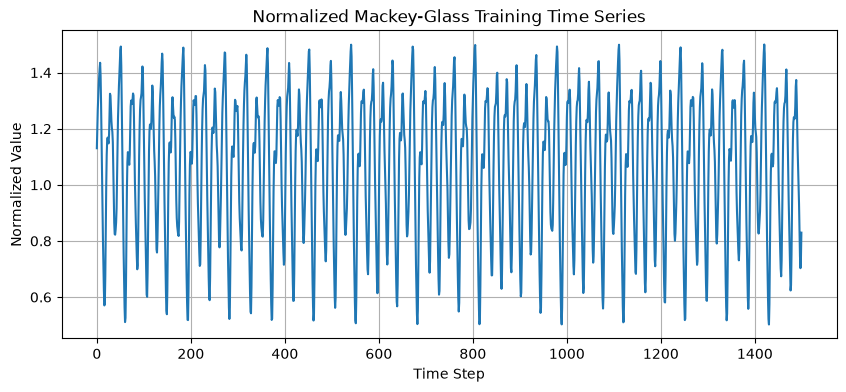

In [15]:
# --- Main Execution Script ---

# Step 1: Generate Mackey-Glass time series
print("Generating Mackey-Glass time series...")

training_length = 1500 # 150 #0
testing_length = 500 #50 #0
time_series_length = training_length + testing_length

# Using the same dt as before for consistency in dynamics
mg_series = generate_mackey_glass_series(time_series_length, dt=2)

# Normalize the time series to be between 0 and 1 to prevent issues with negative inputs
# and population measurements.
mg_series_norm = (mg_series - np.min(mg_series)) / (np.max(mg_series) - np.min(mg_series)) + 0.5

# mg_series_norm = mg_series

# Split into training and testing
train_series = mg_series_norm[:training_length]
test_series = mg_series_norm[training_length:]

# Plot the normalized training time series for inspection
plt.figure(figsize=(10, 4))
# plt.plot(mg_series)
plt.plot(train_series)
plt.title('Normalized Mackey-Glass Training Time Series')
plt.xlabel('Time Step')
plt.ylabel('Normalized Value')
plt.grid(True)
plt.show()

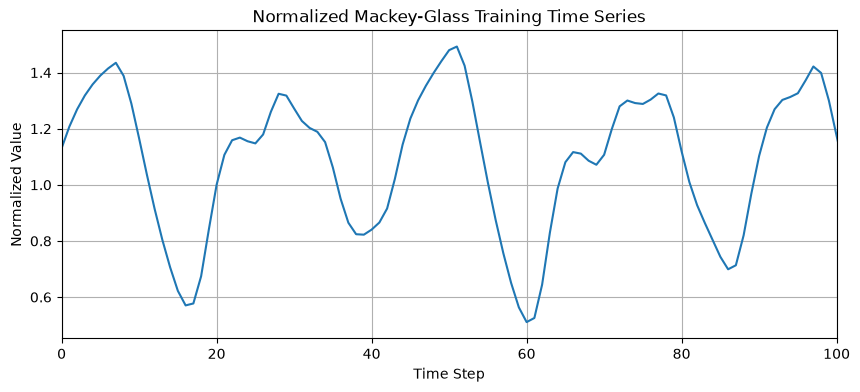

In [16]:
# Plot the normalized training time series for inspection
plt.figure(figsize=(10, 4))
# plt.plot(mg_series)
plt.plot(train_series)
plt.title('Normalized Mackey-Glass Training Time Series')
plt.xlabel('Time Step')
plt.ylabel('Normalized Value')
plt.xlim(0,100)
plt.grid(True)
plt.show()

In [17]:
# Step 2: Quantum Dynamics Simulation & Feature Extraction
print("Running quantum simulations to build feature matrices...")

# Parameters
window_size = 20 #30 # Number of preceding data points
N_cavity = 10 #20    # Hilbert space dimension
kappa_cavity = 2.7 #2 # 2.7 #0.1 #0.1 # Cavity photon loss rate
num_readout_states = 5 #15 # P(|0>) to P(|4>)

# Build F_train matrix
features_train = []
for i in range(training_length - window_size):
    input_window = 1 * train_series[i : i + window_size]
    readout_probs = run_cavity_simulation(input_window, N_cavity, kappa_cavity, num_readout_states=num_readout_states)
    features_train.append(readout_probs)
F_train = np.array(features_train).T # Transpose to get a shape of (num_readout_states x num_training_samples)

# --- New Plot: Fock State Population vs. Training Data Sample ---
plt.figure(figsize=(10, 6))
for n in range(num_readout_states):
    # We need the n-th row of F_train, which corresponds to the n-th Fock state population
    plt.plot(F_train[n, :], label=f'P(|{n}>)')

plt.xlabel('Training Data Sample Index')
plt.ylabel('Probability')
plt.title('Fock State Probabilities vs. Training Data Sample')
plt.legend()
plt.grid(True)
plt.show()
# --- End New Plotting Section ---

# Build F_test matrix
features_test = []
for i in range(testing_length - window_size):
    input_window = test_series[i : i + window_size]
    readout_probs = run_cavity_simulation(input_window, N_cavity, kappa_cavity, num_readout_states=num_readout_states)
    features_test.append(readout_probs)
F_test = np.array(features_test).T

print(f"F_train matrix shape: {F_train.shape}")
print(f"F_test matrix shape: {F_test.shape}")



Running quantum simulations to build feature matrices...


NameError: name 'options' is not defined

In [ ]:
# --- New Plot: Fock State Population vs. Training Data Sample ---
plt.figure(figsize=(10, 6))
for n in range(num_readout_states):
    # We need the n-th row of F_train, which corresponds to the n-th Fock state population
    plt.plot(F_train[n, :], label=f'P(|{n}>)')

plt.xlabel('Training Data Sample Index')
plt.ylabel('Probability')
plt.title('Fock State Probabilities vs. Training Data Sample')
plt.ylim(0,0.2)
plt.xlim(0,100)
# plt.legend()
plt.grid(True)
plt.show()
# --- End New Plotting Section ---

NameError: name 'F_train' is not defined

<Figure size 1000x600 with 0 Axes>

In [ ]:
# Step 3 & 4: Training, Testing, and Evaluation for different delays 'p'
print("\nTraining and evaluating for different prediction delays 'p'...")

max_delay = 25 # Reduced to accommodate the smaller dataset
nrmse_results = []

# Store predictions for plotting later
all_predictions = {}

for p in range(1, max_delay + 1):
    # The number of training samples for both features and targets must be the same
    num_train_samples = training_length - window_size - p
    
    # Check if we have enough samples for this delay
    if num_train_samples <= 0:
        print(f"Not enough training samples for delay p = {p}. Skipping.")
        nrmse_results.append(np.nan)
        continue
        
    y_train_targets = train_series[window_size + p : training_length]
    
    # Select the correct number of samples from the F_train matrix
    F_train_trimmed = F_train[:, :num_train_samples]
    
    # Explicitly reshape y_train to a 2D row vector to prevent matrix multiplication errors
    y_train = y_train_targets[:num_train_samples].reshape(1, -1)
    
    # Calculate Weight Matrix W
    F_train_pinv = np.linalg.pinv(F_train_trimmed)
    W = y_train @ F_train_pinv
    
    # The number of testing samples for both features and targets must be the same
    num_test_samples = testing_length - window_size - p
    
    # Check if we have enough samples for this delay
    if num_test_samples <= 0:
        print(f"Not enough testing samples for delay p = {p}. Skipping.")
        nrmse_results.append(np.nan)
        continue
        
    y_test_targets = test_series[window_size + p : testing_length]
    
    # Select the correct number of samples from the F_test matrix
    F_test_trimmed = F_test[:, :num_test_samples]
    
    # Explicitly reshape y_test to a 2D row vector
    y_test = y_test_targets[:num_test_samples].reshape(1, -1)
    
    # Predict on the test data
    y_predicted = W @ F_test_trimmed
    
    # Store predictions for plotting
    all_predictions[p] = (y_test.flatten(), y_predicted.flatten())
    
    # Calculate NRMSE for this delay p
    nrmse = calculate_nrmse(y_predicted.flatten(), y_test.flatten())
    nrmse_results.append(nrmse)
    print(f"Delay p = {p:2d}, NRMSE = {nrmse:.4f}")

# Find the best delay with the minimum NRMSE
# Filter out NaNs before finding the minimum
valid_nrmse_results = np.array(nrmse_results)
valid_nrmse_results = valid_nrmse_results[~np.isnan(valid_nrmse_results)]

if valid_nrmse_results.size > 0:
    best_delay = np.argmin(nrmse_results) + 1
    best_nrmse = nrmse_results[best_delay - 1]
    print(f"\nOptimal prediction delay is d={best_delay} with NRMSE={best_nrmse:.4f}")
else:
    print("\nNo valid NRMSE results were found. Check your training and testing lengths.")
    best_delay = 1
    

# Plotting the NRMSE results
plt.figure(figsize=(5, 3))
plt.plot(range(1, max_delay + 1), nrmse_results, marker='o', linestyle='-', color='black')
plt.xlabel('Delay d', fontsize=14)
plt.ylabel('Normalized Root Mean Squared Error (NRMSE)', fontsize=14)
plt.title('NRMSE vs. Prediction Delay for Mackey-Glass Time Series', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# --- Plot Target vs. Prediction for the optimal delay ---

# Define which delays to plot
delays_to_plot = [1, best_delay, 10] 

plt.figure(figsize=(6, 4))

if best_delay in all_predictions:
    # Plotting the target time series as a solid line
    optimal_y_test, _ = all_predictions[best_delay]
    plt.plot(optimal_y_test, color='#4dd2ff', linewidth=2, label='Target', zorder=2)

# Plotting the predicted time series for selected delays
for p in delays_to_plot:
    if p in all_predictions:
        _, y_predicted = all_predictions[p]
        plt.plot(y_predicted, marker='o', markersize=4, linestyle='--', linewidth=1.5, label=f'Prediction (d={p})', zorder=1)

plt.title(f'Target vs. Prediction for Selected Delays', fontsize=16)
plt.xlabel('Time Step')
plt.ylabel('Normalized Value')
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


Training and evaluating for different prediction delays 'p'...


NameError: name 'F_train' is not defined

In [ ]:
# --- Plot Target vs. Prediction for delay = 1 and the optimal delay ---

# Define which delays to plot (each gets its own panel, since the target is shifted by the delay)
delays_to_plot = [1] if best_delay == 1 else [1, best_delay]

fig, axes = plt.subplots(len(delays_to_plot), 1, figsize=(4, 2 * len(delays_to_plot)), squeeze=False)

for ax, p in zip(axes[:, 0], delays_to_plot):
    if p not in all_predictions:
        continue
    y_test, y_predicted = all_predictions[p]
    nrmse = nrmse_results[p - 1]

    # Plotting the target time series as a solid line
    ax.plot(y_test[0:300], color='#4dd2ff', linewidth=1, label='Target', zorder=2)
    ax.plot(y_predicted[0:300], marker='o', markersize=2, linestyle='--', linewidth=0.75, label=f'Prediction (d={p})', zorder=1)

    ax.set_title(f'd = {p}{" (best)" if p == best_delay else ""}, NRMSE = {nrmse:.4f}', fontsize=10)
    ax.set_xlabel('time step')
    ax.set_ylabel('chaotic time series')
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()

# plt.savefig('prediction.png', dpi=600, transparent=False)
plt.show()
